# Melbourne Bike Share – Hyperparameter Tuning and Evaluation
## Week 9: Model Optimisation and Performance Breakdown

**Project 8: Urban Bike Sharing Demand Prediction with Graphical Learning**  
**Chameleon – MOP DS, AI & IoT | Deakin University T1 2026**  
**Author: Viswa Sai Mandava**

---

This notebook builds on the baseline XGBoost models from week 8.
It covers:
- Hyperparameter tuning using GridSearchCV to improve model performance
- Comparison of tuned vs baseline model performance
- Per-station performance breakdown (which stations are hardest to predict)
- Per-hour performance breakdown (which hours are hardest to predict)

## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load and Prepare Dataset

In [6]:
df = pd.read_csv('74id-aqj9.csv', low_memory=False)

df['RUNDATE'] = df['RUNDATE'].astype(str)
df['datetime'] = pd.to_datetime(df['RUNDATE'], format='%Y%m%d%H%M%S', errors='coerce')

df['hour']        = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month']       = df['datetime'].dt.month
df['year']        = df['datetime'].dt.year
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

df = df.dropna(subset=['datetime', 'NBBIKES', 'NBEMPTYDOCKS'])
df = df.sort_values(['NAME', 'datetime']).reset_index(drop=True)

# Lag and rolling features
for lag in [1, 2, 3, 6]:
    df[f'bikes_lag_{lag}'] = df.groupby('NAME')['NBBIKES'].shift(lag)
    df[f'docks_lag_{lag}'] = df.groupby('NAME')['NBEMPTYDOCKS'].shift(lag)

df['bikes_roll_3'] = df.groupby('NAME')['NBBIKES'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df['docks_roll_3'] = df.groupby('NAME')['NBEMPTYDOCKS'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df['bikes_roll_6'] = df.groupby('NAME')['NBBIKES'].transform(
    lambda x: x.shift(1).rolling(6, min_periods=1).mean())
df['docks_roll_6'] = df.groupby('NAME')['NBEMPTYDOCKS'].transform(
    lambda x: x.shift(1).rolling(6, min_periods=1).mean())

le = LabelEncoder()
df['station_encoded'] = le.fit_transform(df['NAME'])

df = df.dropna(subset=[f'bikes_lag_{l}' for l in [1,2,3,6]] +
                       [f'docks_lag_{l}' for l in [1,2,3,6]])

print(f'Dataset ready. Shape: {df.shape}')

Dataset ready. Shape: (5643885, 35)


## 3. Define Features and Split

In [8]:
feature_cols = [
    'hour', 'day_of_week', 'month', 'year', 'is_weekend',
    'station_encoded',
    'bikes_lag_1', 'bikes_lag_2', 'bikes_lag_3', 'bikes_lag_6',
    'docks_lag_1', 'docks_lag_2', 'docks_lag_3', 'docks_lag_6',
    'bikes_roll_3', 'bikes_roll_6',
    'docks_roll_3', 'docks_roll_6'
]

X = df[feature_cols]
y_bikes = df['NBBIKES']
y_docks = df['NBEMPTYDOCKS']

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_bikes_train = y_bikes.iloc[:split_idx]
y_bikes_test  = y_bikes.iloc[split_idx:]
y_docks_train = y_docks.iloc[:split_idx]
y_docks_test  = y_docks.iloc[split_idx:]

# Keep test slice of df for per-station and per-hour analysis
df_test = df.iloc[split_idx:].copy()

print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')

Train size: 4,515,108 | Test size: 1,128,777


## 4. Baseline Model Results (from Week 8)

Recorded here for comparison against the tuned models.

In [10]:
baseline = pd.DataFrame({
    'Model': ['Baseline XGBoost – Bikes', 'Baseline XGBoost – Docks'],
    'MAE':  [0.1363, 0.1438],
    'RMSE': [0.4823, 0.4839],
    'R²':   [0.9901, 0.9864]
})

print('Baseline results from Week 8:')
print(baseline.to_string(index=False))

Baseline results from Week 8:
                   Model    MAE   RMSE     R²
Baseline XGBoost – Bikes 0.1363 0.4823 0.9901
Baseline XGBoost – Docks 0.1438 0.4839 0.9864


## 5. Hyperparameter Tuning – Bike Availability Model

We use GridSearchCV with 3-fold cross-validation on a sample of the training data to find better hyperparameters.
A sample is used to keep computation time manageable.

In [12]:
# Sample 10% of training data for grid search (to keep it fast)
sample_idx = np.random.choice(len(X_train), size=int(len(X_train)*0.1), replace=False)
X_train_sample = X_train.iloc[sample_idx]
y_bikes_sample = y_bikes_train.iloc[sample_idx]

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_base = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)

print('Running GridSearchCV for bike model (this may take a few minutes)...')
grid_bikes = GridSearchCV(
    xgb_base, param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
grid_bikes.fit(X_train_sample, y_bikes_sample)

print(f'\nBest parameters for Bike model:')
print(grid_bikes.best_params_)

Running GridSearchCV for bike model (this may take a few minutes)...
Fitting 3 folds for each of 54 candidates, totalling 162 fits

Best parameters for Bike model:
{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


In [13]:
# Train tuned bike model on full training set
tuned_bikes = XGBRegressor(**grid_bikes.best_params_, random_state=42, n_jobs=-1, verbosity=0)
print('Training tuned bike model on full training set...')
tuned_bikes.fit(X_train, y_bikes_train)

bikes_tuned_pred = tuned_bikes.predict(X_test)

mae_bikes_tuned  = mean_absolute_error(y_bikes_test, bikes_tuned_pred)
rmse_bikes_tuned = np.sqrt(mean_squared_error(y_bikes_test, bikes_tuned_pred))
r2_bikes_tuned   = r2_score(y_bikes_test, bikes_tuned_pred)

print(f'\n=== Tuned Bike Model Results ===')
print(f'MAE  : {mae_bikes_tuned:.4f}  (baseline: 0.1363)')
print(f'RMSE : {rmse_bikes_tuned:.4f}  (baseline: 0.4823)')
print(f'R²   : {r2_bikes_tuned:.4f}  (baseline: 0.9901)')

Training tuned bike model on full training set...

=== Tuned Bike Model Results ===
MAE  : 0.1274  (baseline: 0.1363)
RMSE : 0.4804  (baseline: 0.4823)
R²   : 0.9902  (baseline: 0.9901)


## 6. Hyperparameter Tuning – Empty Dock Model

In [15]:
y_docks_sample = y_docks_train.iloc[sample_idx]

print('Running GridSearchCV for dock model...')
grid_docks = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
grid_docks.fit(X_train_sample, y_docks_sample)

print(f'\nBest parameters for Dock model:')
print(grid_docks.best_params_)

Running GridSearchCV for dock model...
Fitting 3 folds for each of 54 candidates, totalling 162 fits

Best parameters for Dock model:
{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


In [16]:
tuned_docks = XGBRegressor(**grid_docks.best_params_, random_state=42, n_jobs=-1, verbosity=0)
print('Training tuned dock model on full training set...')
tuned_docks.fit(X_train, y_docks_train)

docks_tuned_pred = tuned_docks.predict(X_test)

mae_docks_tuned  = mean_absolute_error(y_docks_test, docks_tuned_pred)
rmse_docks_tuned = np.sqrt(mean_squared_error(y_docks_test, docks_tuned_pred))
r2_docks_tuned   = r2_score(y_docks_test, docks_tuned_pred)

print(f'\n=== Tuned Dock Model Results ===')
print(f'MAE  : {mae_docks_tuned:.4f}  (baseline: 0.1438)')
print(f'RMSE : {rmse_docks_tuned:.4f}  (baseline: 0.4839)')
print(f'R²   : {r2_docks_tuned:.4f}  (baseline: 0.9864)')

Training tuned dock model on full training set...

=== Tuned Dock Model Results ===
MAE  : 0.1329  (baseline: 0.1438)
RMSE : 0.4805  (baseline: 0.4839)
R²   : 0.9866  (baseline: 0.9864)


## 7. Tuned vs Baseline Comparison

In [18]:
comparison = pd.DataFrame({
    'Model': [
        'Baseline – Bikes', 'Tuned – Bikes',
        'Baseline – Docks', 'Tuned – Docks'
    ],
    'MAE':  [0.1363, round(mae_bikes_tuned,4), 0.1438, round(mae_docks_tuned,4)],
    'RMSE': [0.4823, round(rmse_bikes_tuned,4), 0.4839, round(rmse_docks_tuned,4)],
    'R²':   [0.9901, round(r2_bikes_tuned,4), 0.9864, round(r2_docks_tuned,4)]
})

print('=== Tuned vs Baseline Comparison ===')
print(comparison.to_string(index=False))

=== Tuned vs Baseline Comparison ===
           Model    MAE   RMSE     R²
Baseline – Bikes 0.1363 0.4823 0.9901
   Tuned – Bikes 0.1274 0.4804 0.9902
Baseline – Docks 0.1438 0.4839 0.9864
   Tuned – Docks 0.1329 0.4805 0.9866


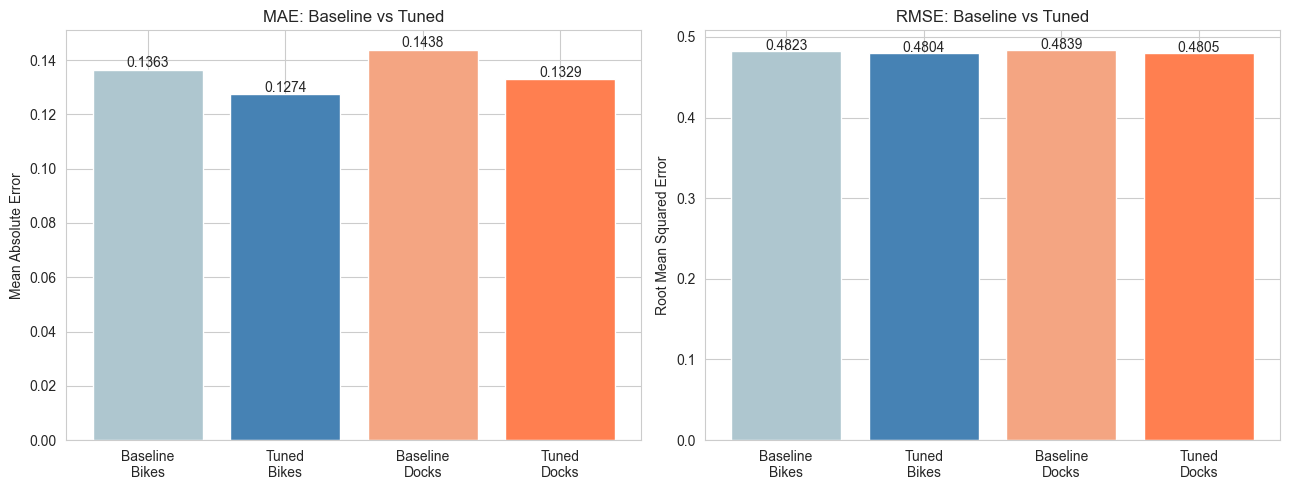

Plot saved.


In [19]:
# Visualise MAE improvement
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ['Baseline\nBikes', 'Tuned\nBikes', 'Baseline\nDocks', 'Tuned\nDocks']
maes  = [0.1363, mae_bikes_tuned, 0.1438, mae_docks_tuned]
rmses = [0.4823, rmse_bikes_tuned, 0.4839, rmse_docks_tuned]
colors = ['#aec6cf', 'steelblue', '#f4a582', 'coral']

axes[0].bar(labels, maes, color=colors, edgecolor='white')
axes[0].set_title('MAE: Baseline vs Tuned')
axes[0].set_ylabel('Mean Absolute Error')
for i, v in enumerate(maes):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

axes[1].bar(labels, rmses, color=colors, edgecolor='white')
axes[1].set_title('RMSE: Baseline vs Tuned')
axes[1].set_ylabel('Root Mean Squared Error')
for i, v in enumerate(rmses):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('tuned_vs_baseline.png', dpi=150)
plt.show()
print('Plot saved.')

## 8. Per-Station Performance Breakdown

Which stations are hardest to predict accurately?

In [21]:
df_test = df_test.copy()
df_test['bikes_pred'] = bikes_tuned_pred
df_test['docks_pred'] = docks_tuned_pred
df_test['bikes_error'] = (df_test['NBBIKES'] - df_test['bikes_pred']).abs()
df_test['docks_error'] = (df_test['NBEMPTYDOCKS'] - df_test['docks_pred']).abs()

station_mae = df_test.groupby('NAME')['bikes_error'].mean().sort_values(ascending=False)

print('Top 10 hardest stations to predict (Bike Availability):')
print(station_mae.head(10).round(4))

print('\nTop 10 easiest stations to predict (Bike Availability):')
print(station_mae.tail(10).round(4))

Top 10 hardest stations to predict (Bike Availability):
NAME
St Kilda - Luna Park                                       0.4288
St Paul's Cathedral - Swanston St/ Flinders St - City      0.2941
St Kilda West - West Beach Pavilion                        0.2598
St Kilda - Fitzroy Street                                  0.2510
St Kilda - Cleve Gardens                                   0.2086
Swanston St (East) / Flinders St (St Pauls)                0.1939
West Beach Pavilion - Beaconsfield Pde - St Kilda West     0.1597
St Paul's Cathedral - Swanston St / Flinders St - City     0.1557
Swanston St / Little Lonsdale St                           0.1550
State Library - Swanston St / Little Lonsdale St - City    0.1490
Name: bikes_error, dtype: float32

Top 10 easiest stations to predict (Bike Availability):
NAME
VCAM - St Kilda Rd / Southbank Blvd                     0.1299
VCAM - St Kilda Rd / Southbank Blvd - Southbank         0.1197
Yarra's Edge - River Esp / Yarra River - Docklands      0

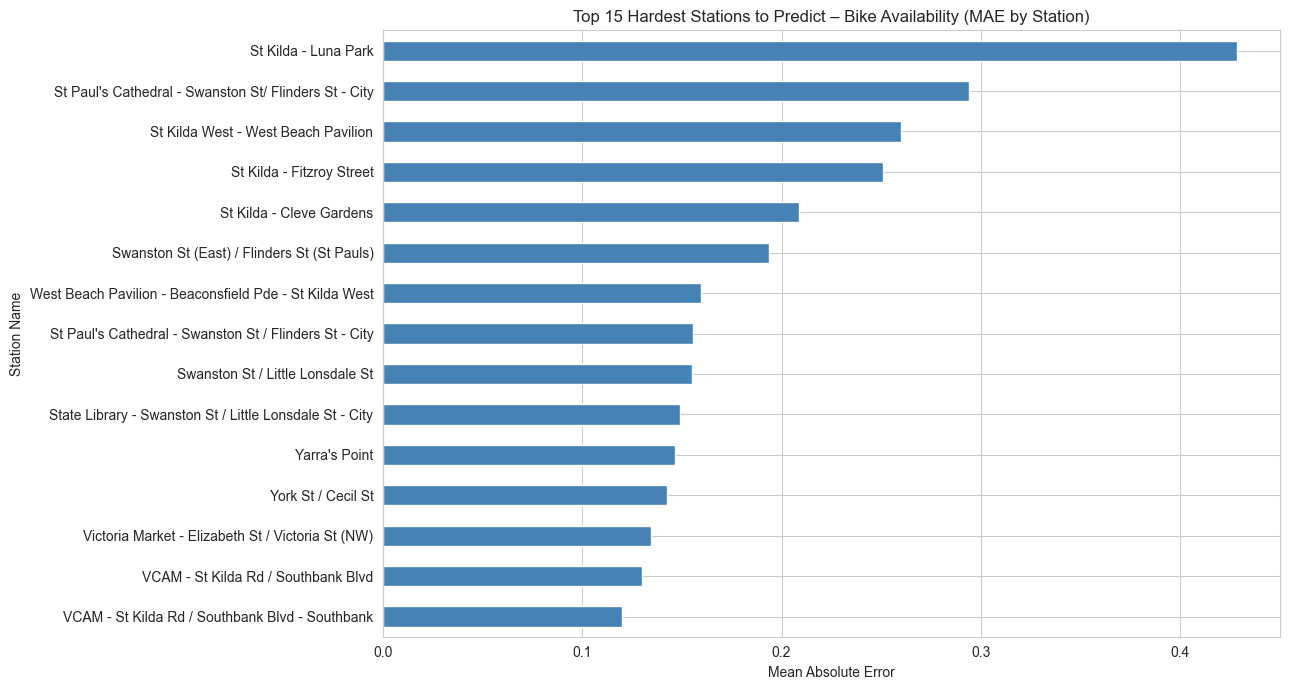

Plot saved.


In [22]:
fig, ax = plt.subplots(figsize=(13, 7))
station_mae.head(15).sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 15 Hardest Stations to Predict – Bike Availability (MAE by Station)')
ax.set_xlabel('Mean Absolute Error')
ax.set_ylabel('Station Name')
plt.tight_layout()
plt.savefig('per_station_mae.png', dpi=150)
plt.show()
print('Plot saved.')

## 9. Per-Hour Performance Breakdown

Which hours of the day are hardest to predict?

MAE by hour of day (Bike Availability):
hour
0     0.0330
1     0.0212
2     0.0169
3     0.0136
4     0.0130
5     0.0163
6     0.0245
7     0.0511
8     0.1227
9     0.1109
10    0.1305
11    0.1724
12    0.2065
13    0.2508
14    0.2503
15    0.2659
16    0.2617
17    0.2718
18    0.2283
19    0.1743
20    0.1333
21    0.1079
22    0.0851
23    0.0710
Name: bikes_error, dtype: float32


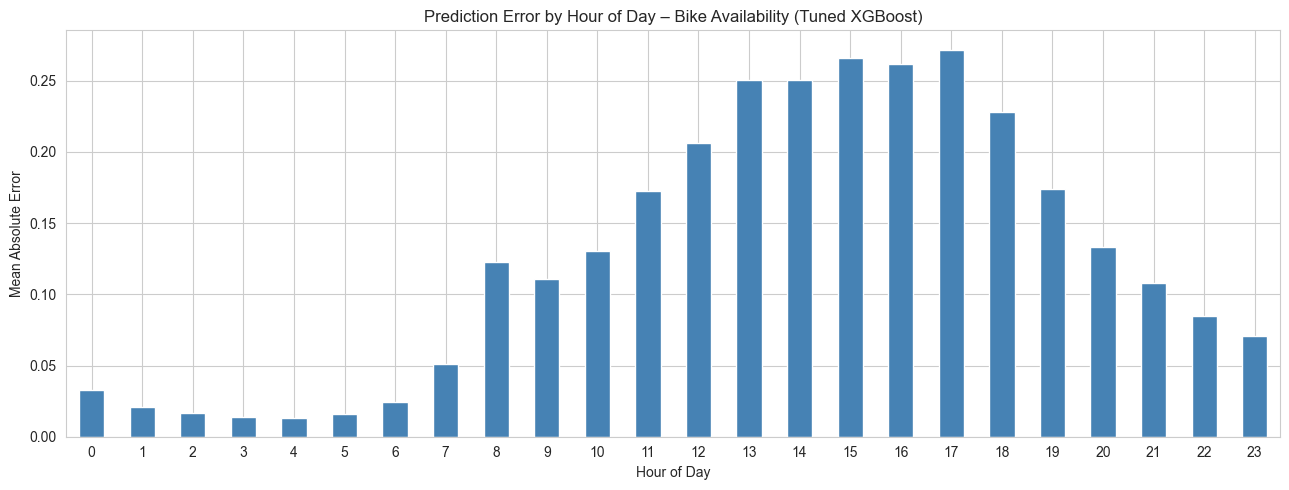

Plot saved.


In [24]:
hourly_mae = df_test.groupby('hour')['bikes_error'].mean().round(4)

print('MAE by hour of day (Bike Availability):')
print(hourly_mae)

fig, ax = plt.subplots(figsize=(13, 5))
hourly_mae.plot(kind='bar', color='steelblue', ax=ax, edgecolor='white')
ax.set_title('Prediction Error by Hour of Day – Bike Availability (Tuned XGBoost)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Absolute Error')
ax.set_xticklabels(range(0, 24), rotation=0)
plt.tight_layout()
plt.savefig('per_hour_mae.png', dpi=150)
plt.show()
print('Plot saved.')

## 10. Summary

In [26]:
print('=== Week 9 Summary ===')
print(f'Tuned Bike Model  — MAE: {mae_bikes_tuned:.4f} | RMSE: {rmse_bikes_tuned:.4f} | R²: {r2_bikes_tuned:.4f}')
print(f'Tuned Dock Model  — MAE: {mae_docks_tuned:.4f} | RMSE: {rmse_docks_tuned:.4f} | R²: {r2_docks_tuned:.4f}')
print()
print(f'Improvement in MAE (Bikes): {0.1363 - mae_bikes_tuned:.4f}')
print(f'Improvement in MAE (Docks): {0.1438 - mae_docks_tuned:.4f}')
print()
print('Next steps:')
print('- Integrate all three use cases into a final combined notebook')
print('- Write up findings and limitations')
print('- Prepare final project deliverable')

=== Week 9 Summary ===
Tuned Bike Model  — MAE: 0.1274 | RMSE: 0.4804 | R²: 0.9902
Tuned Dock Model  — MAE: 0.1329 | RMSE: 0.4805 | R²: 0.9866

Improvement in MAE (Bikes): 0.0089
Improvement in MAE (Docks): 0.0109

Next steps:
- Integrate all three use cases into a final combined notebook
- Write up findings and limitations
- Prepare final project deliverable
